# Import libraries and load data

In [82]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
# Load the data
df = pd.read_csv('nba.csv')

# Data Exploration

In [84]:
# Get top 5 records, by default 5 records will fetch
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28.0,NaN,22.0,6-5,185.0,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8.0,PF,NaN,6-10,231.0,NaN,5000000.0


In [85]:
# Get bottom 6 records
df.tail(6)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
452,Trey Lyles,Utah Jazz,41.0,PF,20.0,6-10,234.0,Kentucky,2239800.0
453,Shelvin Mack,Utah Jazz,8.0,PG,26.0,6-3,203.0,Butler,2433333.0
454,Raul Neto,Utah Jazz,25.0,PG,24.0,6-1,179.0,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21.0,C,26.0,7-3,256.0,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24.0,C,26.0,7-0,231.0,Kansas,947276.0
457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
# Get no.of columns and rows
df.shape

(458, 9)

In [87]:
# Get data information about data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      457 non-null    object 
 1   Team      456 non-null    object 
 2   Number    457 non-null    float64
 3   Position  456 non-null    object 
 4   Age       456 non-null    float64
 5   Height    457 non-null    object 
 6   Weight    457 non-null    float64
 7   College   373 non-null    object 
 8   Salary    446 non-null    float64
dtypes: float64(4), object(5)
memory usage: 32.3+ KB


In [88]:
# Get statistical summary, by default gives only mumeric columns
df.describe()

,Number,Age,Weight,Salary
count,457.000000,456.000000,457.000000,4.460000e+02
mean,17.678337,26.934211,221.522976,4.842684e+06
std,15.966090,4.407792,26.368343,5.229238e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.044792e+06
50%,13.000000,26.000000,220.000000,2.839073e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


# Data Cleaning

### Handling missing data

In [89]:
# Detecting missing values, True for null
df.isnull()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True
3,False,False,False,True,False,False,False,False,False
4,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...
453,False,False,False,False,False,False,False,False,False
454,False,False,False,False,False,False,False,True,False
455,False,False,False,False,False,False,False,True,False
456,False,False,False,False,False,False,False,False,False


In [90]:
# Detecting missing counts
df.isnull().sum()

Name         1
Team         2
Number       1
Position     2
Age          2
Height       1
Weight       1
College     85
Salary      12
dtype: int64

In [91]:
# Get only nan values for specific column
df[df["College"].isnull()]

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
4,Jonas Jerebko,Boston Celtics,8.0,PF,NaN,6-10,231.0,NaN,5000000.0
5,Amir Johnson,Boston Celtics,90.0,PF,29.0,6-9,240.0,NaN,12000000.0
15,Bojan Bogdanovic,NaN,44.0,SG,27.0,6-8,216.0,NaN,3425510.0
20,Sergey Karasev,Brooklyn Nets,10.0,SG,22.0,6-7,208.0,NaN,1599840.0
32,Thanasis Antetokounmpo,New York Knicks,43.0,SF,23.0,6-7,205.0,NaN,30888.0
...,...,...,...,...,...,...,...,...,...
447,Rudy Gobert,Utah Jazz,27.0,C,23.0,7-1,245.0,NaN,1175880.0
450,Joe Ingles,Utah Jazz,2.0,SF,28.0,6-8,226.0,NaN,2050000.0
454,Raul Neto,Utah Jazz,25.0,PG,24.0,6-1,179.0,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21.0,C,26.0,7-3,256.0,NaN,2900000.0


In [92]:
# Get only nan values for all column
df[df.isnull().any(axis=1)]

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28.0,NaN,22.0,6-5,185.0,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8.0,PF,NaN,6-10,231.0,NaN,5000000.0
5,Amir Johnson,Boston Celtics,90.0,PF,29.0,6-9,240.0,NaN,12000000.0
15,Bojan Bogdanovic,NaN,44.0,SG,27.0,6-8,216.0,NaN,3425510.0
...,...,...,...,...,...,...,...,...,...
447,Rudy Gobert,Utah Jazz,27.0,C,23.0,7-1,245.0,NaN,1175880.0
450,Joe Ingles,Utah Jazz,2.0,SF,28.0,6-8,226.0,NaN,2050000.0
454,Raul Neto,Utah Jazz,25.0,PG,24.0,6-1,179.0,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21.0,C,26.0,7-3,256.0,NaN,2900000.0


In [93]:
# Dropping rows will all values are nan
df.dropna(how="all", inplace=True)
df.isnull().sum()

Name         0
Team         1
Number       0
Position     1
Age          1
Height       0
Weight       0
College     84
Salary      11
dtype: int64

In [94]:
# Drop missing values for specific columns
df.dropna(subset=["Name", "Team"], inplace=True)
df.isnull().sum()

Name         0
Team         0
Number       0
Position     1
Age          1
Height       0
Weight       0
College     83
Salary      11
dtype: int64

In [95]:
# Filling missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df.isnull().sum()
df[df["Team"].isnull()]

,Name,Team,Number,Position,Age,Height,Weight,College,Salary


In [96]:
# Filling values with forward fill
df["Position"] = df["Position"].ffill()
df.isnull().sum()

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     83
Salary      11
dtype: int64

In [121]:
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())
df.isnull().sum()

C:\Users\464_0743\AppData\Local\Temp\ipykernel_19644\1209686509.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Salary"] = df["Salary"].fillna(df["Salary"].mean())


index           0
Student Name    0
Team            0
Number          0
Position        0
Age             0
Weight          0
College         0
Salary          0
dtype: int64

In [122]:
# Filling values with backward fill
df["College"] = df["College"].bfill()
df.isnull().sum()

C:\Users\464_0743\AppData\Local\Temp\ipykernel_19644\2022388395.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["College"] = df["College"].bfill()


index           0
Student Name    0
Team            0
Number          0
Position        0
Age             0
Weight          0
College         0
Salary          0
dtype: int64

# Removing duplicates

In [123]:
# Getting duplicated rows
df[df.duplicated()]

,index,Student Name,Team,Number,Position,Age,Weight,College,Salary


In [124]:
# Get duplicated row count
df.duplicated().sum()

np.int64(0)

In [125]:
# Removing duplicates
df.drop_duplicates(subset=["Team", "Name"], keep='first')

KeyError: Index(['Name'], dtype='object')

# Data type conversion

In [126]:
# Convert to integer
df["Number"] = df["Number"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         453 non-null    int64  
 1   Student Name  453 non-null    object 
 2   Team          453 non-null    object 
 3   Number        453 non-null    int64  
 4   Position      453 non-null    object 
 5   Age           453 non-null    float64
 6   Weight        453 non-null    float64
 7   College       453 non-null    object 
 8   Salary        453 non-null    float64
dtypes: float64(3), int64(2), object(4)
memory usage: 32.0+ KB


C:\Users\464_0743\AppData\Local\Temp\ipykernel_19644\2272105726.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Number"] = df["Number"].astype(int)


In [127]:
# Convert to string
df["Name"] = df["Name"].astype(str)
df.info()

KeyError: 'Name'

In [ ]:
# Convert all to best dtypes
df.convert_dtypes()
df.info()

# Renaming and Reshaping

In [ ]:
# Renaming column names
df.rename(columns={'Name':'Student Name'}, inplace=True)

In [ ]:
# Resetting index
df.reset_index(drop=True)

In [ ]:
# Setting new index
df.set_index('Student Name')

# String Data cleaning

In [128]:
# Remove white spaces
df['Team'] = df['Team'].str.strip()
df.head()

C:\Users\464_0743\AppData\Local\Temp\ipykernel_19644\1093101300.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Team'] = df['Team'].str.strip()


,index,Student Name,Team,Number,Position,Age,Weight,College,Salary
0,2,John Holland,Boston Celtics,30,SG,30.0,205.0,Boston University,4.818518e+06
1,3,R.J. Hunter,Boston Celtics,28,SG,30.0,185.0,Georgia State,1.148640e+06
2,4,Jonas Jerebko,Boston Celtics,8,PF,30.0,231.0,LSU,5.000000e+06
3,5,Amir Johnson,Boston Celtics,90,PF,30.0,240.0,LSU,1.200000e+07
4,6,Jordan Mickey,Boston Celtics,55,PF,30.0,235.0,LSU,1.170960e+06


# Removing rows and columns

In [129]:
# Removing rows
df.drop([0, 1], axis=0, inplace=True)
df.head()

C:\Users\464_0743\AppData\Local\Temp\ipykernel_19644\1460059454.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop([0, 1], axis=0, inplace=True)


,index,Student Name,Team,Number,Position,Age,Weight,College,Salary
2,4,Jonas Jerebko,Boston Celtics,8,PF,30.0,231.0,LSU,5000000.0
3,5,Amir Johnson,Boston Celtics,90,PF,30.0,240.0,LSU,12000000.0
4,6,Jordan Mickey,Boston Celtics,55,PF,30.0,235.0,LSU,1170960.0
5,7,Kelly Olynyk,Boston Celtics,41,C,30.0,238.0,Gonzaga,2165160.0
6,8,Terry Rozier,Boston Celtics,12,PG,30.0,190.0,Louisville,1824360.0


In [130]:
# Removing columns
df.drop(['Height'], axis=1, inplace=True)
df.head()

KeyError: "['Height'] not found in axis"

# Outlier & Invalid Data Handling

In [ ]:
age_df = df[df['Age'] > 30]
age_df

In [ ]:
# Update age less then lower will become lower and bigger then upper will become upper
df['Age'] = df['Age'].clip(lower=30, upper=32)
df

In [131]:
# Removing outliers with IQR
Q1 = df["Number"].quantile(0.25)
Q3 = df["Number"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["Number"] >= lower) | (df["Number"] <= upper)]
df

,index,Student Name,Team,Number,Position,Age,Weight,College,Salary
2,4,Jonas Jerebko,Boston Celtics,8,PF,30.0,231.0,LSU,5000000.0
3,5,Amir Johnson,Boston Celtics,90,PF,30.0,240.0,LSU,12000000.0
4,6,Jordan Mickey,Boston Celtics,55,PF,30.0,235.0,LSU,1170960.0
5,7,Kelly Olynyk,Boston Celtics,41,C,30.0,238.0,Gonzaga,2165160.0
6,8,Terry Rozier,Boston Celtics,12,PG,30.0,190.0,Louisville,1824360.0
...,...,...,...,...,...,...,...,...,...
448,452,Trey Lyles,Utah Jazz,41,PF,30.0,234.0,Kentucky,2239800.0
449,453,Shelvin Mack,Utah Jazz,8,PG,30.0,203.0,Butler,2433333.0
450,454,Raul Neto,Utah Jazz,25,PG,30.0,179.0,Kansas,900000.0
451,455,Tibor Pleiss,Utah Jazz,21,C,30.0,256.0,Kansas,2900000.0


In [132]:
# Removing outliers with Z-score
z_score = (df["Weight"] - df["Weight"].mean()) / df["Weight"].std()
df = df[np.abs(z_score) <= 3]
df

,index,Student Name,Team,Number,Position,Age,Weight,College,Salary
2,4,Jonas Jerebko,Boston Celtics,8,PF,30.0,231.0,LSU,5000000.0
3,5,Amir Johnson,Boston Celtics,90,PF,30.0,240.0,LSU,12000000.0
4,6,Jordan Mickey,Boston Celtics,55,PF,30.0,235.0,LSU,1170960.0
5,7,Kelly Olynyk,Boston Celtics,41,C,30.0,238.0,Gonzaga,2165160.0
6,8,Terry Rozier,Boston Celtics,12,PG,30.0,190.0,Louisville,1824360.0
...,...,...,...,...,...,...,...,...,...
448,452,Trey Lyles,Utah Jazz,41,PF,30.0,234.0,Kentucky,2239800.0
449,453,Shelvin Mack,Utah Jazz,8,PG,30.0,203.0,Butler,2433333.0
450,454,Raul Neto,Utah Jazz,25,PG,30.0,179.0,Kansas,900000.0
451,455,Tibor Pleiss,Utah Jazz,21,C,30.0,256.0,Kansas,2900000.0


In [133]:
df.describe()

,index,Number,Age,Weight,Salary
count,451.000000,451.000000,451.000000,451.000000,4.510000e+02
mean,230.088692,17.436807,30.354767,221.525499,4.826656e+06
std,130.552233,15.515222,0.732177,26.085435,5.182857e+06
min,4.000000,0.000000,30.000000,161.000000,3.088800e+04
25%,117.500000,5.000000,30.000000,200.000000,1.087084e+06
50%,230.000000,13.000000,30.000000,220.000000,2.854940e+06
75%,342.500000,25.000000,30.000000,240.000000,6.285000e+06
max,456.000000,92.000000,32.000000,290.000000,2.500000e+07


In [134]:
df

,index,Student Name,Team,Number,Position,Age,Weight,College,Salary
2,4,Jonas Jerebko,Boston Celtics,8,PF,30.0,231.0,LSU,5000000.0
3,5,Amir Johnson,Boston Celtics,90,PF,30.0,240.0,LSU,12000000.0
4,6,Jordan Mickey,Boston Celtics,55,PF,30.0,235.0,LSU,1170960.0
5,7,Kelly Olynyk,Boston Celtics,41,C,30.0,238.0,Gonzaga,2165160.0
6,8,Terry Rozier,Boston Celtics,12,PG,30.0,190.0,Louisville,1824360.0
...,...,...,...,...,...,...,...,...,...
448,452,Trey Lyles,Utah Jazz,41,PF,30.0,234.0,Kentucky,2239800.0
449,453,Shelvin Mack,Utah Jazz,8,PG,30.0,203.0,Butler,2433333.0
450,454,Raul Neto,Utah Jazz,25,PG,30.0,179.0,Kansas,900000.0
451,455,Tibor Pleiss,Utah Jazz,21,C,30.0,256.0,Kansas,2900000.0


In [135]:
# Reset index after deleting some rows
df.reset_index(inplace=True)

In [136]:
df

,level_0,index,Student Name,Team,Number,Position,Age,Weight,College,Salary
0,2,4,Jonas Jerebko,Boston Celtics,8,PF,30.0,231.0,LSU,5000000.0
1,3,5,Amir Johnson,Boston Celtics,90,PF,30.0,240.0,LSU,12000000.0
2,4,6,Jordan Mickey,Boston Celtics,55,PF,30.0,235.0,LSU,1170960.0
3,5,7,Kelly Olynyk,Boston Celtics,41,C,30.0,238.0,Gonzaga,2165160.0
4,6,8,Terry Rozier,Boston Celtics,12,PG,30.0,190.0,Louisville,1824360.0
...,...,...,...,...,...,...,...,...,...,...
446,448,452,Trey Lyles,Utah Jazz,41,PF,30.0,234.0,Kentucky,2239800.0
447,449,453,Shelvin Mack,Utah Jazz,8,PG,30.0,203.0,Butler,2433333.0
448,450,454,Raul Neto,Utah Jazz,25,PG,30.0,179.0,Kansas,900000.0
449,451,455,Tibor Pleiss,Utah Jazz,21,C,30.0,256.0,Kansas,2900000.0


In [137]:
df.isnull().sum()

level_0         0
index           0
Student Name    0
Team            0
Number          0
Position        0
Age             0
Weight          0
College         0
Salary          0
dtype: int64

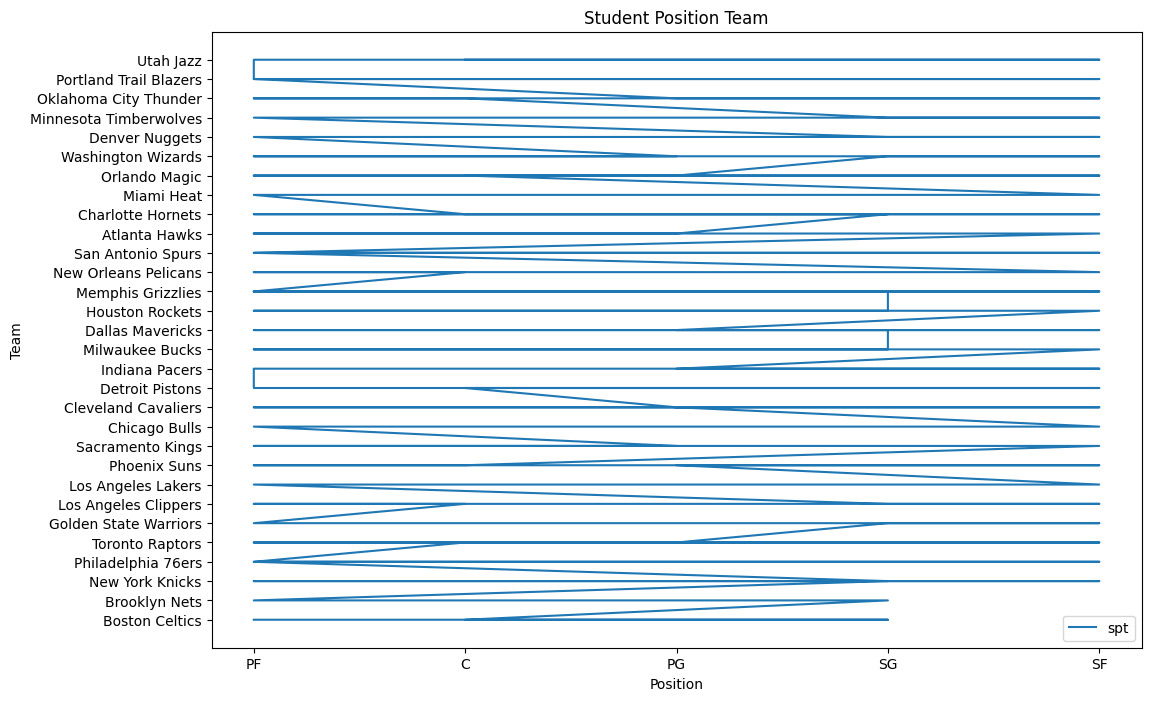

In [155]:
# line graph
plt.figure(figsize=(12,8))

plt.plot(df["Position"], df["Team"], label="spt")

plt.xlabel("Position")
plt.ylabel("Team")
plt.title("Student Position Team")

plt.legend()
plt.show()

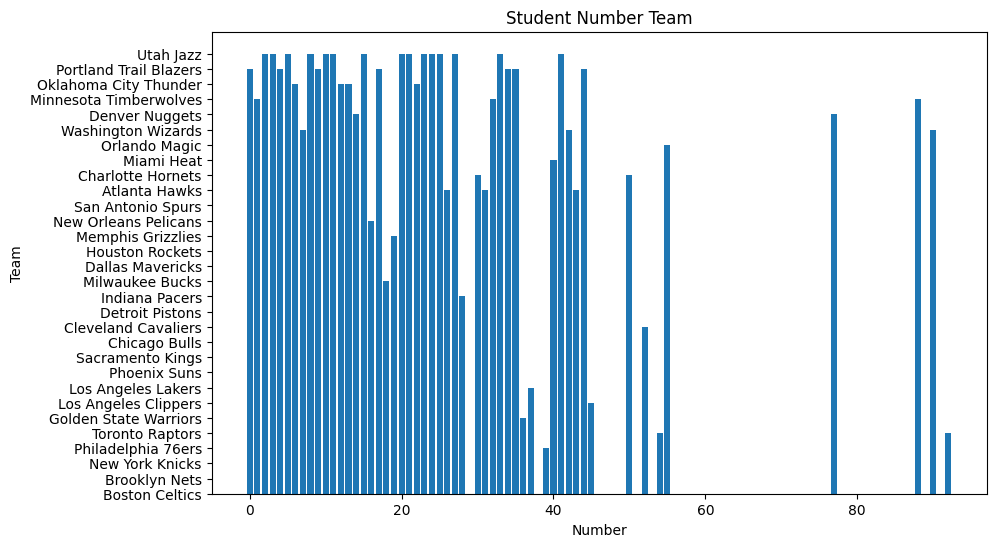

In [154]:
# Bar graph
plt.figure(figsize=(10, 6))

plt.bar(df["Number"], df["Team"])
plt.xlabel("Number")
plt.ylabel("Team")
plt.title("Student Number Team")

plt.show()

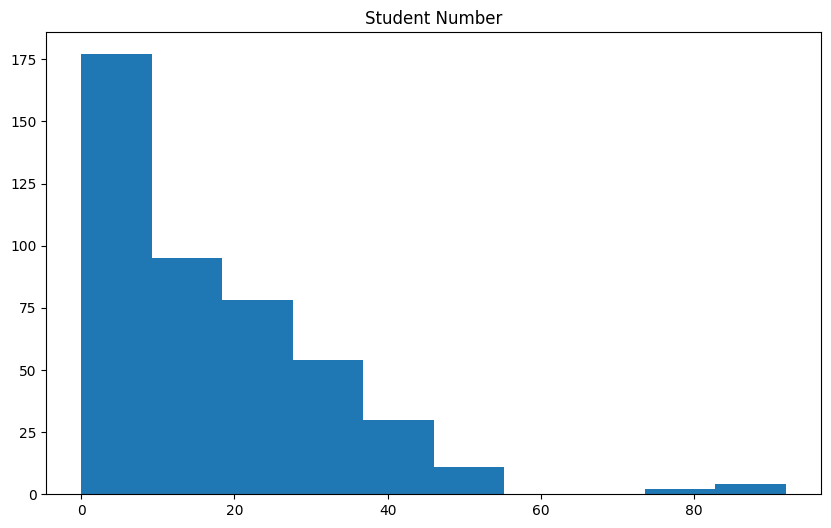

In [158]:
plt.figure(figsize=(10, 6))

plt.hist(df["Number"], bins=10)
plt.title('Student Number')

plt.show()

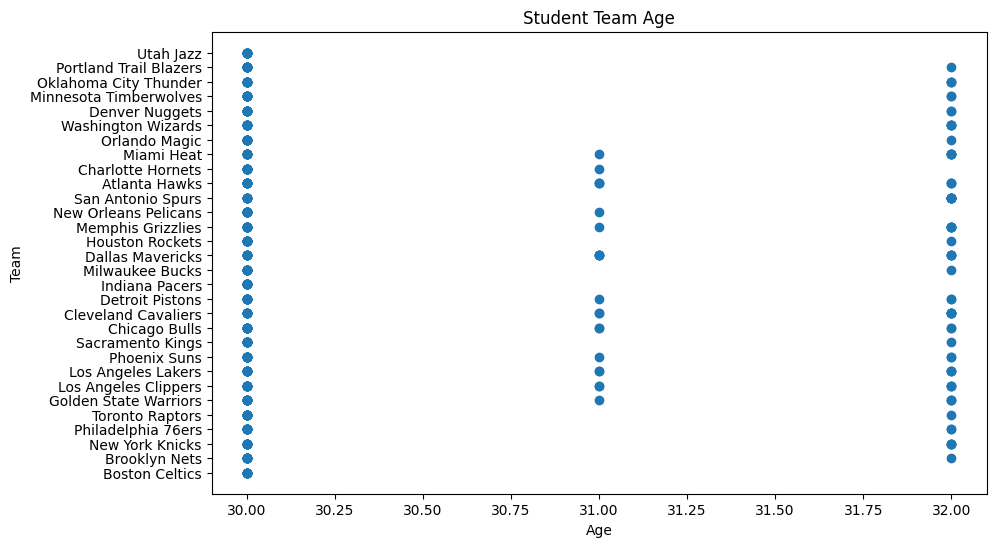

In [163]:
plt.figure(figsize=(10, 6))

plt.scatter(df["Age"], df["Team"])
plt.xlabel('Age')
plt.ylabel('Team')
plt.title('Student Team Age')

plt.show()